# 디스크 용량 확인 !!

In [7]:
!FLUX/bin/pip install ipykernel

In [1]:
!FLUX/bin/python -m ipykernel install --user --name=FLUX --display-name "FLUX"

Installed kernelspec FLUX in /root/.local/share/jupyter/kernels/flux


In [8]:
!FLUX/bin/pip list

Package                  Version
------------------------ -----------
absl-py                  2.3.1
accelerate               1.10.1
aiohappyeyeballs         2.6.1
aiohttp                  3.12.15
aiosignal                1.4.0
annotated-types          0.7.0
asttokens                3.0.0
attrs                    25.3.0
bitsandbytes             0.47.0
certifi                  2025.8.3
charset-normalizer       3.4.3
click                    8.2.1
comm                     0.2.3
datasets                 4.0.0
debugpy                  1.8.16
decorator                5.2.1
diffusers                0.36.0.dev0
dill                     0.3.8
executing                2.2.0
filelock                 3.19.1
frozenlist               1.7.0
fsspec                   2025.3.0
ftfy                     6.3.1
gitdb                    4.0.12
GitPython                3.1.45
grpcio                   1.74.0
hf-xet                   1.1.8
huggingface-hub          0.34.4
idna                     3.10
importlib

In [3]:
!pip install dotenv


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


In [1]:
!pip list

Package                   Version
------------------------- ------------------------
anyio                     4.9.0
argon2-cffi               23.1.0
argon2-cffi-bindings      21.2.0
arrow                     1.3.0
asttokens                 3.0.0
async-lru                 2.0.5
attrs                     25.3.0
babel                     2.17.0
beautifulsoup4            4.13.3
bleach                    6.2.0
blinker                   1.4
certifi                   2025.1.31
cffi                      1.17.1
charset-normalizer        3.4.1
comm                      0.2.2
cryptography              3.4.8
dbus-python               1.2.18
debugpy                   1.8.13
decorator                 5.2.1
defusedxml                0.7.1
distro                    1.7.0
executing                 2.2.0
fastjsonschema            2.21.1
filelock                  3.16.1
fqdn                      1.5.1
fsspec                    2024.10.0
h11                       0.14.0
httpcore                  1.0.7
ht

In [2]:
# CLIP scoring 프롬프트가 잘 반영되었는지.
# import torch
# import json
# from diffusers.utils import load_image
# from transformers import CLIPProcessor, CLIPModel
# from PIL import Image
# from tqdm import tqdm
import os
from dotenv import load_dotenv
from huggingface_hub import login
load_dotenv("key.env")
hf_api_key = os.getenv("HUGGINGFACE_API_KEY")
login(hf_api_key)
print("log-in")


# 실험 결과를 항상 동일하게 재현하려고 설정
# seed = 42
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

log-in


In [7]:
# FID, CLIP dir
# data_dir = "Validation/FID/Image_Text"
test_dir = "./Dataset/test"
# CLIP_prompts = "Dataset/test/prompts/CLIP_test_prompts.json"
# base_dir = "./test/2_base"
# os.makedirs(base_dir, exist_ok=True)
# LoRA_dir = "./test/2_LoRA_half"
# os.makedirs(LoRA_dir, exist_ok=True)

# out_base_only_design_dir = "Validation/77/base/70"
# os.makedirs(out_base_only_design_dir, exist_ok=True)
# out_base_quarter_design_dir = "Validation/77/base/20_50"
# os.makedirs(out_base_quarter_design_dir, exist_ok=True)
# out_fine_only_design_dir = "Validation/77/fine/70"
# os.makedirs(out_fine_only_design_dir, exist_ok=True)
# out_fine_quarter_design_dir = "Validation/77/fine/20_50"
# os.makedirs(out_fine_quarter_design_dir, exist_ok=True)


# test dataset의 image-text쌍의 text load (_2.txt 제외)
file_list = sorted([
    f for f in os.listdir(test_dir)
    if f.endswith(".txt") and not f.endswith("_2.txt")
])
print(file_list)

# test_subset = sorted(file_list[:10])

# print(test_subset)
# 평가용 프롬프트 Json load
# with open(CLIP,prompts, encoding="utf-8") as f:
#     prompt_data = json.load(f)
# CLIP_test_prompts = [item["prompt"] for item in prompt_data]

# with open("/workspace/prompts/only_design_prompts.json", encoding="utf-8") as f:
#     prompt_data = json.load(f)
# only_design_prompts = [item["prompt"] for item in prompt_data]

# with open("/workspace/prompts/quarter_design_prompts.json", encoding="utf-8") as f:
#     prompt_data = json.load(f)
# quarter_design_prompts = [item["prompt"] for item in prompt_data]

print("data load")

['Hyundai-Clix_Concept-2001-thb.txt', 'Hyundai-HCD-14_Genesis_Concept-2013-thb.txt', 'Hyundai-Hexa_Space_Concept-2012-thb.txt', 'Hyundai-Intrado_Concept-2014-thb.txt', 'Hyundai-Nuvis_Concept-2009-thb.txt', 'Hyundai-QarmaQ_Concept-2007-thb.txt', 'Hyundai-RM19_Concept-2019-thb.txt', 'Hyundai-Santa_Cruz_Crossover_Truck_Concept-2015-thb.txt', 'Hyundai-Veloster_Concept-2007-thb.txt', 'Hyundai-Vision_T_Concept-2019-thb.txt', 'Hyundai-i-flow_Concept-2010-thb.txt', 'Large-40336-2020SonataHybrid-Limited-HamptonGray.txt', 'Large-40343-2020SonataHybrid-SEL-HamptonGray.txt', 'Large-40593-2021Elantra.txt', 'Large-41251-2021Veloster.txt', 'Large-41338-2021VelosterTurbo.txt', 'Large-41383-2021VelosterTurbo.txt', 'Large-41607-2021Palisade.txt', 'Large-41871-2021VelosterN.txt', 'Large-42000-2021Kona.txt', 'Large-42002-2021HyundaiTucson.txt', 'Large-42085-2021Tucson.txt', 'Large-42091-2021Tucson.txt', 'Large-42113-2021Tucson.txt', 'Large-42117-2021Tucson.txt', 'Large-42253-2021NEXO.txt', 'Large-42407-20

In [3]:
prompt_2 = (
    "You are generating a highly detailed text-to-image prompt for a car design model. "
    "The goal is to create a realistic Hyundai concept car image that strictly maintains the correct automobile form "
    "(no human figures, no distorted objects, no unrelated content) with sharp outlines and complete body visible. "
    "The generated prompt should enforce the following constraints:\n"
    "1. Viewpoint: clear 3/4 front view of the entire car, with proper perspective, proportions, and wheel alignment.\n"
    "2. Body form: accurate automobile silhouette, well-defined roofline, hood, trunk, and greenhouse. "
    "No missing parts, no cropped edges, no blurred boundaries.\n"
    "3. Design language: incorporate Hyundai’s design philosophy (Sensuous Sportiness, Parametric Pixel details, "
    "clean aerodynamic curves, sharp shoulder lines, taut body surfacing).\n"
    "4. Exterior details: angular grille, distinctive headlights and taillights, sculpted hood, "
    "aerodynamic side mirrors, flush door handles, sharp window line, short overhangs, proper dash-to-axle ratio.\n"
    "5. Wheels and stance: 19-inch multi-spoke wheels, low-profile tires, wide stance, low beltline, sporty proportions.\n"
    "6. Materials and finish: metallic paint, photorealistic reflections, no cartoon or abstract style.\n"
    "7. Background: neutral studio lighting or soft outdoor daylight, with emphasis on car clarity and edge sharpness.\n"
    "8. Negative constraints: absolutely no humans, text overlays, watermarks, distorted wheels, cropped body, "
    "excessive background clutter, or unrealistic textures.\n"
    "Generate a fluent English text description that integrates all these constraints naturally into one continuous prompt, "
    "up to the maximum token limit, so the image model can produce a sharp, realistic, full-body Hyundai car design rendering."
)


negative_prompt = (
    "cartoon, illustration, sketch, anime, cgi, hand-drawn, "
    "side view, top view, cropped, out of frame, truncated, incomplete, "
    "rotating wheel, extra wheels, extra doors, text, watermark, logo, "
    "outdoor, street, colored background, cut, clutter, "
    "reflection, shadow, frame, border, blurry, low quality"
)

negative_prompt_2 = (
    "You are generating a negative prompt for a car design image model. "
    "The goal is to strictly forbid the generation of any elements that would distort, degrade, or distract "
    "from a clean, photorealistic Hyundai automobile rendering. "
    "List all forbidden aspects clearly, so the image generator avoids them completely.\n"
    "1. No humans, human parts, faces, bodies, or figures inside or outside the car.\n"
    "2. No cropped, cut-off, or incomplete vehicles; the full car body must always be visible.\n"
    "3. No blurred, foggy, noisy, pixelated, low-resolution, or distorted edges.\n"
    "4. No warped, melted, or deformed car shapes (wheels, roofline, hood, doors, headlights, etc.).\n"
    "5. No double exposure, ghosting, duplicate wheels, overlapping body panels, or extra limbs.\n"
    "6. No text, watermarks, logos, signatures, captions, or overlay graphics in the image.\n"
    "7. No cartoon, sketch, anime, comic, abstract, or artistic styles; only photorealism is allowed.\n"
    "8. No surreal or unrelated objects (people, animals, buildings, furniture, clouds inside the car, "
    "random patterns, extra tires, floating shapes, unrealistic props).\n"
    "9. No extreme fisheye, distorted wide-angle, or unnatural camera perspectives.\n"
    "10. No excessive background clutter, distracting scenery, irrelevant items, or messy environments.\n"
    "11. No incorrect lighting such as harsh glare, overexposed highlights, unrealistic neon, "
    "or inconsistent shadows that break realism.\n"
    "12. No wrong materials or textures: avoid plastic-like finish, muddy colors, watercolor style, "
    "or artificial surfaces.\n"
    "13. No cropped wheels, missing tires, distorted rims, or unaligned axles.\n"
    "14. No incomplete rendering artifacts such as half-rendered doors, broken reflections, "
    "or faded outlines near the car’s border.\n"
    "15. No bizarre modifications (wings, rocket boosters, tanks, weapons, fantasy elements).\n"
    "16. No duplicate or misplaced emblems; ensure the Hyundai logo appears only once in the correct position on the front of the car.\n"
    "Generate a fluent, comprehensive negative prompt that integrates all these forbidden constraints into one "
    "continuous text block, maximizing the token budget, to help the image model avoid any unrealistic, "
    "distorted, or irrelevant outputs."
)

In [9]:
import torch
from diffusers import FluxKontextPipeline
# from diffusers.utils import load_image

# 베이스 모델
pipe_base = FluxKontextPipeline.from_pretrained("black-forest-labs/FLUX.1-Kontext-dev", torch_dtype=torch.bfloat16)
pipe_base.to("cuda")

# 시드 고정된 generator
generator = torch.Generator(device="cuda").manual_seed(seed)

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  4.21it/s]


In [ ]:
base_dir = "./test/base_prompt_2_add"
os.makedirs(base_dir, exist_ok=True)
# 이미지 생성
for fname in file_list:
    txt_path = os.path.join(test_dir, f"{fname}")
    print(txt_path)
    with open(txt_path, "r", encoding="utf-8") as f:
        prompt = f.read().strip()
    image = pipe_base(
    prompt=prompt,
    prompt_2=prompt_2,
    negative_prompt=negative_prompt,
    negative_prompt_2=negative_prompt_2,
    num_inference_steps=50,
    true_cfg_scale=1.8,
    guidance_scale=9.0,
    generator=generator
    ).images[0]
    image.save(os.path.join(base_dir, f"{fname[:-4]}_base.jpg"))

# 메모리 해제
del pipe_base
torch.cuda.empty_cache()

Token indices sequence length is longer than the specified maximum sequence length for this model (84 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['aerodynamic curves, metallic silver paint']


./Dataset/test/Hyundai-Clix_Concept-2001-thb.txt


100%|██████████| 50/50 [01:16<00:00,  1.54s/it]


./Dataset/test/Hyundai-HCD-14_Genesis_Concept-2013-thb.txt


100%|██████████| 50/50 [01:21<00:00,  1.63s/it]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['low - profile tires, tinted mirrors, b - pillars, roof rails, panoramic dlo, glossy metallic blue paint']


...

100%|██████████| 50/50 [01:25<00:00,  1.70s/it]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['low - profile tires, panoramic roof rails, tinted greenhouse, chrome accents, dark metallic paint']


./Dataset/test/Large-47846-2022SantaFeXRT.txt


100%|██████████| 50/50 [01:25<00:00,  1.70s/it]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', roof rails, clear headlamps, led drl, tinted greenhouse, chrome trim, metallic beige paint']


./Dataset/test/Large-48002-2022SantaCruz.txt


 46%|████▌     | 23/50 [00:38<00:46,  1.71s/it]

In [4]:
import torch
from diffusers import FluxKontextPipeline
# LoRA 모델
pipe_LoRA = FluxKontextPipeline.from_pretrained("black-forest-labs/FLUX.1-Kontext-dev", torch_dtype=torch.bfloat16)

# fine_path = "/workspace/output/test2_models/checkpoint-1000"  # LoRA 파라미터 폴더/파일 경로
# pipe_fine.load_lora_weights(fine_path, weight_name="pytorch_lora_weights.safetensors")
adapter_id = 'mingyu-oo/FLUX_LoRA_adapter'
pipe_LoRA.load_lora_weights(adapter_id, weight_name="pytorch_lora_weights.safetensors")
pipe_LoRA.fuse_lora(lora_scale=0.5)
pipe_LoRA.enable_vae_slicing()
pipe_LoRA.enable_vae_tiling()
pipe_LoRA.to("cuda")

# # 시드 고정된 generator
# generator = torch.Generator(device="cuda").manual_seed(seed)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


FluxKontextPipeline {
  "_class_name": "FluxKontextPipeline",
  "_diffusers_version": "0.36.0.dev0",
  "_name_or_path": "black-forest-labs/FLUX.1-Kontext-dev",
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "T5EncoderModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "T5TokenizerFast"
  ],
  "transformer": [
    "diffusers",
    "FluxTransformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [2]:
from diffusers import FluxKontextPipeline
from huggingface_hub import HfApi
import torch

# 1) 모델 불러오기
pipe_LoRA = FluxKontextPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-Kontext-dev",
    torch_dtype=torch.float32
).to("cuda")

# 2) LoRA 로드
adapter_id = 'mingyu-oo/FLUX_LoRA_adapter'
pipe_LoRA.load_lora_weights(adapter_id, weight_name="pytorch_lora_weights.safetensors")

# 3) LoRA 절반만 fuse
pipe_LoRA.fuse_lora(lora_scale=0.5)

model_index.json:   0%|          | 0.00/688 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

pytorch_lora_weights.safetensors:   0%|          | 0.00/108M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


In [3]:
# 4) LoRA 모듈 제거 (빈 메타 텐서 제거)
pipe_LoRA.unload_lora_weights()

# 5) 저장
pipe_LoRA.to(torch.float16) # fuse 연산은 안정적인 fp32에서 하고, 저장할 때만 fp16으로 변환
save_path = "./FLUX_HD_LoRA_model"
pipe_LoRA.save_pretrained(save_path)

# 6) 허깅페이스 업로드
api = HfApi()
repo_id = "mingyu-oo/FLUX_HD_LoRA_model"
api.create_repo(repo_id=repo_id, exist_ok=True)
api.upload_folder(
    repo_id=repo_id,
    folder_path=save_path,
    commit_message="Upload FLUX.1-Kontext-dev fused with LoRA (0.5 scale)"
)

print(f"🚀 업로드 완료: https://huggingface.co/{repo_id}")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...diffusion_pytorch_model.safetensors:  25%|##4       | 41.9MB /  168MB            

  ...odel/text_encoder/model.safetensors:  20%|##        | 50.3MB /  246MB            

  ...ch_model-00002-of-00003.safetensors:   0%|          |  525kB / 9.95GB            

...

  ..._2/model-00001-of-00002.safetensors:   1%|1         | 58.7MB / 4.99GB            

  ...ch_model-00001-of-00003.safetensors:   0%|          | 14.2kB / 9.98GB            

  ..._2/model-00002-of-00002.safetensors:   1%|1         | 50.2MB / 4.53GB            

  ...ch_model-00003-of-00003.safetensors:   1%|          | 33.3MB / 3.87GB            

🚀 업로드 완료: https://huggingface.co/mingyu-oo/FLUX_HD_LoRA_model


In [ ]:
from diffusers import FluxKontextPipeline
import torch

pipe = FluxKontextPipeline.from_pretrained(
    "mingyu-oo/FLUX_HD_LoRA_model",
    torch_dtype=torch.float16,
).to("cuda")

model_index.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

text_encoder/model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

text_encoder_2/model-00001-of-00003.safe(…):   0%|          | 0.00/4.99G [00:00<?, ?B/s]

text_encoder_2/model-00001-of-00002.safe(…):   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/554 [00:00<?, ?B/s]

transformer/diffusion_pytorch_model-0000(…):   0%|          | 0.00/9.98G [00:00<?, ?B/s]

transformer/diffusion_pytorch_model-0000(…):   0%|          | 0.00/9.95G [00:00<?, ?B/s]

transformer/diffusion_pytorch_model-0000(…):   0%|          | 0.00/3.87G [00:00<?, ?B/s]

In [18]:
from huggingface_hub import upload_file, notebook_login
from pathlib import Path

# 1️⃣ Hugging Face 로그인
# notebook_login()  # 토큰 인증

# 2️⃣ 로컬 LoRA 디렉토리
local_dir = Path("/workspace/FLUX_HD_LoRA_adapter")  # 경로 수정 가능

# 3️⃣ 업로드할 파일 확장자 설정
allowed_exts = [".safetensors", ".bin", ".json", ".png"]

# 4️⃣ 허브 repo 정보
repo_id = "mingyu-oo/FLUX_HD_ES6"  # 기존 업로드 모델
repo_type = "model"

# 5️⃣ 디렉토리 순회하며 업로드
for file_path in local_dir.rglob("*"):
    if file_path.suffix.lower() in allowed_exts:
        relative_path = file_path.relative_to(local_dir)
        print(f"Uploading {relative_path} ...")
        upload_file(
            path_or_fileobj=str(file_path),
            path_in_repo=str(relative_path),
            repo_id=repo_id,
            repo_type=repo_type,
            token=True  # 로그인 토큰 사용
        )

print("✅ 모든 파일 업로드 완료!")


Uploading image_3.png ...


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            
New Data Upload                         : |          |  0.00B /  0.00B            

  ...ce/FLUX_HD_LoRA_adapter/image_3.png: 100%|██████████|  737kB /  737kB            

Processing Files (1 / 1)                : 100%|██████████|  737kB /  737kB, 1.23MB/s  

  ...ce/FLUX_HD_LoRA_adapter/image_3.png: 100%|██████████|  737kB /  737kB            

  ...ce/FLUX_HD_LoRA_adapter/image_3.png: 100%|██████████|  737kB /  737kB            

Processing Files (1 / 1)                : 100%|██████████|  737kB /  737kB,  737kB/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...ce/FLUX_HD_LoRA_adapter/image_3.png: 100%|██████████|  737kB /  737kB            


Uploading image_2.png ...


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            
New Data Upload                         : |          |  0.00B /  0.00B            

  ...ce/FLUX_HD_LoRA_adapter/image_2.png: 100%|██████████|  932kB /  932kB            

Processing Files (1 / 1)                : 100%|██████████|  932kB /  932kB,   ???B/s  

  ...ce/FLUX_HD_LoRA_adapter/image_2.png: 100%|██████████|  932kB /  932kB            

Processing Files (1 / 1)                : 100%|██████████|  932kB /  932kB,  0.00B/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...ce/FLUX_HD_LoRA_adapter/image_2.png: 100%|██████████|  932kB /  932kB            


Uploading image_1.png ...


...

Uploading checkpoint-200/optimizer.bin ...


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            
New Data Upload                         : |          |  0.00B /  0.00B            

  ...dapter/checkpoint-200/optimizer.bin:  23%|██▎       | 25.1MB /  111MB            

Processing Files (0 / 1)                :  23%|██▎       | 25.1MB /  111MB,   ???B/s  

Processing Files (0 / 1)                :  53%|█████▎    | 58.7MB /  111MB,  168MB/s  

Processing Files (0 / 1)                :  83%|████████▎ | 92.1MB /  111MB,  167MB/s  

Processing Files (1 / 1)                : 100%|██████████|  111MB /  111MB,  143MB/s  

  ...dapter/checkpoint-200/optimizer.bin: 100%|██████████|  111MB /  111MB            

  ...dapter/checkpoint-200/optimizer.bin: 100%|██████████|  111MB /  111MB            

Processing Files (1 / 1)                : 100%|██████████|  111MB /  111MB, 85.8MB/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...dapter/checkpoint-200/optimizer.bin: 100%|

Uploading checkpoint-200/pytorch_lora_weights.safetensors ...


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            
New Data Upload                         : |          |  0.00B /  0.00B            

  ...00/pytorch_lora_weights.safetensors:  23%|██▎       | 25.2MB /  108MB            

Processing Files (0 / 1)                :  23%|██▎       | 25.2MB /  108MB,   ???B/s  

Processing Files (0 / 1)                :  46%|████▋     | 50.3MB /  108MB,  126MB/s  

Processing Files (0 / 1)                :  70%|██████▉   | 75.5MB /  108MB,  126MB/s  

Processing Files (1 / 1)                : 100%|██████████|  108MB /  108MB,  139MB/s  

  ...00/pytorch_lora_weights.safetensors: 100%|██████████|  108MB /  108MB            

  ...00/pytorch_lora_weights.safetensors: 100%|██████████|  108MB /  108MB            

Processing Files (1 / 1)                : 100%|██████████|  108MB /  108MB, 83.3MB/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...00/pytorch_lora_weights.safetensors: 100%|

✅ 모든 파일 업로드 완료!


Token indices sequence length is longer than the specified maximum sequence length for this model (81 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', metallic silver paint']


  0%|          | 0/10 [00:00<?, ?it/s]

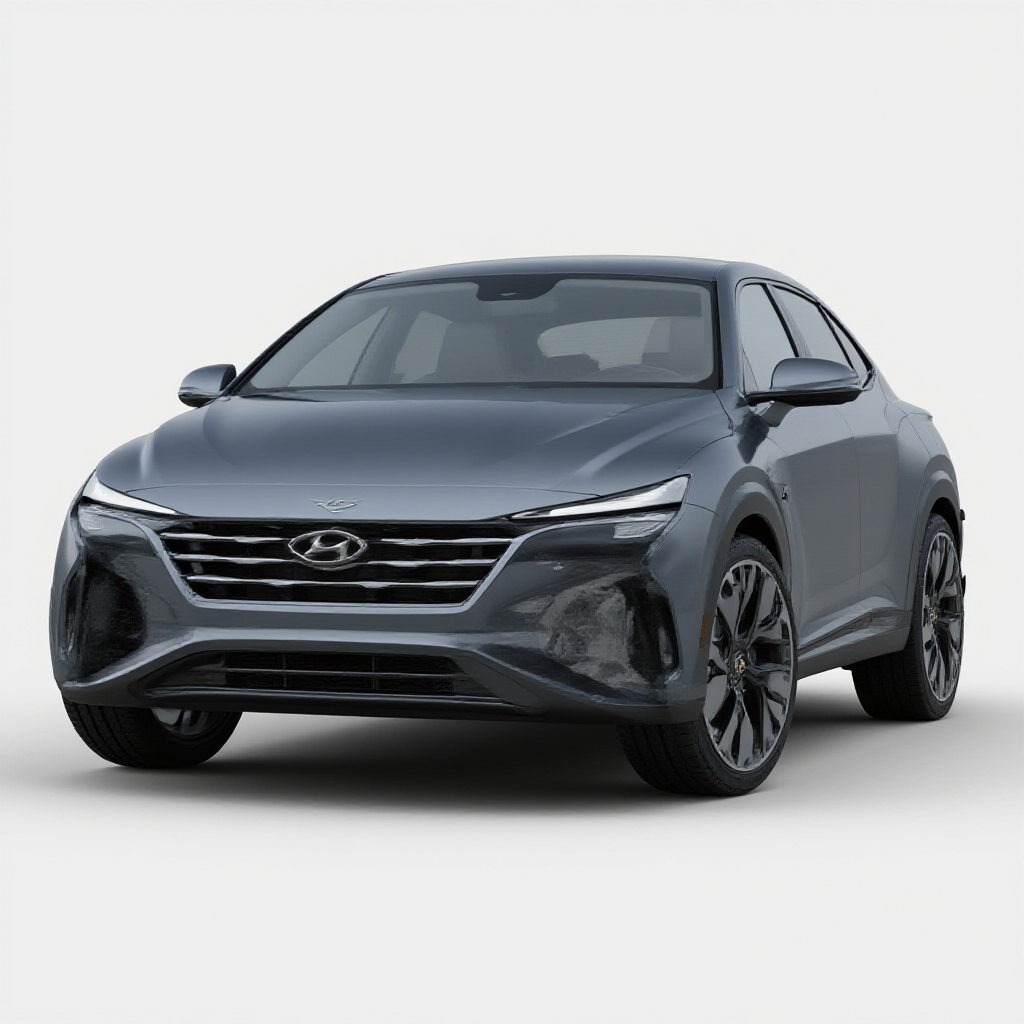

In [5]:
prompt = "Designed by Hyundai, 3/4 front view, sedan, three-box, long wheelbase, wide stance, short overhangs, low beltline, sleek greenhouse, taut body surfacing, aggressive shoulder lines, mesh grille, narrow intakes, sculpted hood, flush door handles, 20-inch alloy wheels, low-profile tires, tinted mirrors, roof rails, metallic silver paint"
# prompt = "pretty cat"
image = pipe_LoRA(
    prompt=prompt,
    prompt_2=prompt_2,
    negative_prompt=negative_prompt,
    negative_prompt_2=negative_prompt_2,
    num_inference_steps=10,
    true_cfg_scale=1.8,
    guidance_scale=9.0,
    generator=torch.Generator(device="cuda").manual_seed(42)
    ).images[0]
image

In [6]:
# 메모리 해제
del pipe
torch.cuda.empty_cache()

In [ ]:
LoRA_dir = "./test/LoRA_prompt_2_add"
os.makedirs(LoRA_dir, exist_ok=True)

for fname in file_list:
    txt_path = os.path.join(test_dir, f"{fname}")
    print(txt_path)
    with open(txt_path, "r", encoding="utf-8") as f:
        prompt = f.read().strip()
    image = pipe_LoRA(
    prompt=prompt,
    prompt_2=prompt_2,
    negative_prompt=negative_prompt,
    negative_prompt_2=negative_prompt_2,
    num_inference_steps=50,
    true_cfg_scale=1.8,
    guidance_scale=9.0,
    generator=generator
    ).images[0]
    image.save(os.path.join(LoRA_dir, f"{fname[:-4]}_LoRA.jpg"))

# 메모리 해제
del pipe_LoRA
torch.cuda.empty_cache()

100%|██████████| 30/30 [00:28<00:00,  1.06it/s]


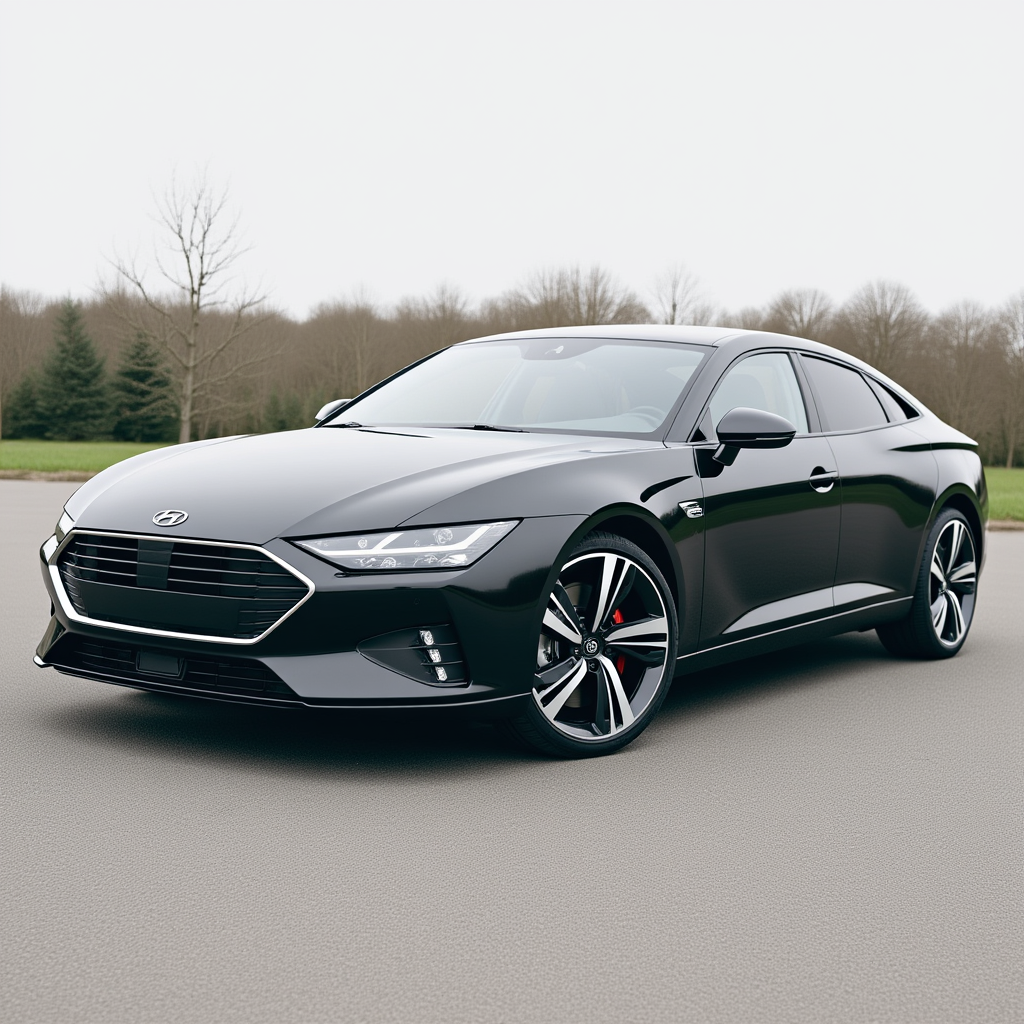

In [8]:
image = pipe_LoRA(
    prompt="Designed by Hyundai, mid-sized sedan, 3/4 front view, two-box shape, long wheelbase, short overhangs, clean body surfacing, parametric grille, pixel DRL headlamps, large alloy wheels, panoramic glass roof, aerodynamic silhouette, matte silver finish, white background",
    prompt_2=prompt_2,
    negative_prompt=negative_prompt,
    negative_prompt_2=negative_prompt_2,
    num_inference_steps=30,
    guidance_scale=9.0,
    generator=generator
    ).images[0]
image

In [15]:
import os
base_dir = "./test/base_prompt_2_add"
LoRA_dir = "./test/LoRA_prompt_2_add"
base_imgs = sorted([f for f in os.listdir(base_dir) if f.lower().endswith(".jpg")])
lora_imgs = sorted([f for f in os.listdir(LoRA_dir) if f.lower().endswith(".jpg")])

print("Base 개수:", len(base_imgs))
print("LoRA 개수:", len(lora_imgs))

# 누락된 인덱스 확인
base_ids = {int(os.path.splitext(f)[0]) for f in base_imgs if f[0].isdigit()}
lora_ids = {int(os.path.splitext(f)[0]) for f in lora_imgs if f[0].isdigit()}

print("Base-only:", sorted(base_ids - lora_ids))
print("LoRA-only:", sorted(lora_ids - base_ids))


Base 개수: 178
LoRA 개수: 178
Base-only: []
LoRA-only: []


In [19]:
import os, json
from tqdm import tqdm
from PIL import Image
import torch
from torchvision import transforms
from transformers import CLIPModel, CLIPProcessor
from torchmetrics.image.fid import FrechetInceptionDistance

# -------------------------------
# CLIP Score 계산
# -------------------------------
def clip_score(image_path, prompt, clip_model, clip_processor, device="cuda", max_len=77):
    image = Image.open(image_path).convert("RGB")
    # 토큰 길이 77로 제한
    tokens = clip_processor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_len)
    truncated_prompt = clip_processor.tokenizer.decode(tokens["input_ids"][0], skip_special_tokens=True)

    inputs = clip_processor(text=[truncated_prompt], images=image, return_tensors="pt", padding=True,
                            truncation=True, max_length=max_len)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = clip_model(**inputs)
        return outputs.logits_per_image.item()

def eval_clip(file_list, test_dir, base_dir, lora_dir, clip_model, clip_processor, device="cuda"):
    base_scores, lora_scores, results = [], [], []

    for fname in tqdm(file_list, desc="CLIP Evaluation"):
        txt_path = os.path.join(test_dir, fname)
        with open(txt_path, "r", encoding="utf-8") as f:
            prompt = f.read().strip()

        base_img = os.path.join(base_dir, f"{fname[:-4]}_base.jpg")
        lora_img = os.path.join(lora_dir, f"{fname[:-4]}_LoRA.jpg")

        b_score = clip_score(base_img, prompt, clip_model, clip_processor, device=device)
        l_score = clip_score(lora_img, prompt, clip_model, clip_processor, device=device)

        base_scores.append(b_score)
        lora_scores.append(l_score)

        results.append({
            "file_name": fname[:-4],
            "prompt": prompt,
            "base_score": b_score,
            "lora_score": l_score,
            "improved": l_score > b_score
        })

    return base_scores, lora_scores, results

# -------------------------------
# FID 계산
# -------------------------------
def compute_fid(real_dir, gen_dir, device="cuda"):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.PILToTensor(),   # uint8로 변환
    ])

    for fname in tqdm(os.listdir(real_dir), desc="Real images"):
        if fname.lower().endswith(".jpg"):
            img = Image.open(os.path.join(real_dir, fname)).convert("RGB")
            fid.update(transform(img).unsqueeze(0).to(device), real=True)

    for fname in tqdm(os.listdir(gen_dir), desc=f"Generated {os.path.basename(gen_dir)}"):
        if fname.lower().endswith(".jpg"):
            img = Image.open(os.path.join(gen_dir, fname)).convert("RGB")
            fid.update(transform(img).unsqueeze(0).to(device), real=False)

    return fid.compute().item()

# -------------------------------
# 메인 실행
# -------------------------------
def main(test_dir, base_dir, lora_dir, real_dir, out_json="evaluation_results.json", device="cuda"):
    # test dataset의 image-text쌍의 text load (_2.txt 제외)
    file_list = sorted([
        f for f in os.listdir(test_dir)
        if f.endswith(".txt") and not f.endswith("_2.txt")
    ])
    
    # 2. CLIP 모델 로드
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

    # 3. CLIP 평가
    base_scores, lora_scores, clip_results = eval_clip(file_list, test_dir, base_dir, lora_dir,
                                                       clip_model, clip_processor, device)

    # 4. FID 평가
    fid_base = compute_fid(real_dir, base_dir, device)
    fid_lora = compute_fid(real_dir, lora_dir, device)

    # 5. 요약
    summary = {
        "CLIP": {
            "base_avg": sum(base_scores)/len(base_scores),
            "lora_avg": sum(lora_scores)/len(lora_scores)
        },
        "FID": {
            "base": fid_base,
            "lora": fid_lora,
            "better": "LoRA" if fid_lora < fid_base else "Base"
        }
    }

    output = {"summary": summary, "clip_details": clip_results}

    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)

    print(f"✅ 평가 완료, 결과 저장: {out_json}")

# -------------------------------
# 실행 예시
# -------------------------------
if __name__ == "__main__":
    test_dir = "./Dataset/test"       # .txt 프롬프트 저장된 곳
    base_dir = "./test/base_prompt_2_add"       # Base 모델 생성 이미지
    lora_dir = "./test/LoRA_prompt_2_add"       # LoRA 모델 생성 이미지
    real_dir = "./Dataset/test" # GT 이미지 경로
    main(test_dir, base_dir, lora_dir, real_dir, out_json="FLUX_eval_results_prompt_2_add.json")


CLIP Evaluation: 100%|██████████| 178/178 [00:25<00:00,  7.05it/s]
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 85.9MB/s]
Generated LoRA_prompt_2_add: 100%|██████████| 179/179 [00:04<00:00, 35.93it/s]


✅ 평가 완료, 결과 저장: FLUX_eval_results_prompt_2_add.json


In [ ]:
import os, json, base64
from tqdm import tqdm
from openai import OpenAI

# OpenAI 클라이언트
client = OpenAI(api_key=)

def encode_image(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def gpt_score(prompt, base_img, lora_img):
    base64_base = encode_image(base_img)
    base64_lora = encode_image(lora_img)

    system_prompt = """아래에 주어진 자동차 디자인 프롬프트와 두 개의 이미지(Base, LoRA)를 비교하세요.

평가 항목:
1. 프롬프트 충실도 (텍스트와 얼마나 잘 맞는지)
2. 디자인 완성도 (차체 비율, 디테일, 일관성)
3. 브랜드 정체성 (현대차 스타일이 유지됐는지)
4. 이미지 품질 (해상도, 노이즈, 아티팩트 여부)

출력은 JSON 형태로:
{
  "prompt_faithfulness": {"base": 1-5, "lora": 1-5},
  "design_quality": {"base": 1-5, "lora": 1-5},
  "brand_identity": {"base": 1-5, "lora": 1-5},
  "image_quality": {"base": 1-5, "lora": 1-5},
  "winner": "Base" 또는 "LoRA",
  "comment": "간단한 이유 (한국어)"
}"""

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": [
                {"type": "text", "text": f"Prompt:\n{prompt}"},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{base64_base}"}},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{base64_lora}"}}
            ]}
        ],
        temperature=0.2,
        max_tokens=300
    )

    raw_output = response.choices[0].message.content.strip()

    # ✅ 코드블록 제거
    if raw_output.startswith("```"):
        raw_output = raw_output.split("```")[1]  # 첫번째 블록 안의 내용만 추출
    raw_output = raw_output.replace("json\n", "", 1).replace("json", "", 1).strip()

    try:
        result = json.loads(raw_output)
    except Exception as e:
        result = {"error": raw_output, "parse_error": str(e)}
    return result


def batch_gpt_score(test_dir, base_dir, lora_dir, out_json="gpt_eval_results.json"):
    # test dataset의 image-text쌍의 text load (_2.txt 제외)
    file_list = sorted([
        f for f in os.listdir(test_dir)
        if f.endswith(".txt") and not f.endswith("_2.txt")
    ])
    all_results = []

    for fname in tqdm(file_list, desc="GPT-Score Evaluation"):
        txt_path = os.path.join(test_dir, fname)
        with open(txt_path, "r", encoding="utf-8") as f:
            prompt = f.read().strip()

        base_img = os.path.join(base_dir, f"{fname[:-4]}_base.jpg")
        lora_img = os.path.join(lora_dir, f"{fname[:-4]}_LoRA.jpg")

        if not (os.path.exists(base_img) and os.path.exists(lora_img)):
            print(f"⚠️ 이미지 누락: {fname[:-4]}.jpg")
            continue

        result = gpt_score(prompt, base_img, lora_img)
        result["file_name"] = fname[:-4]
        result["prompt"] = prompt

        all_results.append(result)

    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)

    print(f"✅ 평가 완료, 결과 저장: {out_json}")


# -------------------------------
# 실행 예시
# -------------------------------
if __name__ == "__main__":
    test_dir = "./Dataset/test"   # 프롬프트 .txt
    base_dir = "./test/base_prompt_2_add"      # Base 모델 생성 이미지
    lora_dir = "./test/LoRA_prompt_2_add"      # LoRA 모델 생성 이미지
    batch_gpt_score(test_dir, base_dir, lora_dir, out_json="GPT_eval_result_prompt_2_add.json")


GPT-Score Evaluation: 100%|██████████| 178/178 [16:03<00:00,  5.41s/it]

✅ 평가 완료, 결과 저장: GPT_eval_result_prompt_2_add.json


In [ ]:
import os
from openai import OpenAI

# 🔑 OpenAI API 키 설정
client = OpenAI(api_key=)

# 🔧 변환 함수
def generate_prompt2(prompt: str) -> str:
    system_msg = (
        "You are an automotive design assistant. "
        "Rewrite the following keywords as a detailed natural language scene description, "
        "focusing on realistic automotive design and photography details. "
        "Keep it natural and descriptive."
    )
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": prompt},
        ],
        temperature=0.7,
        max_tokens=300
    )
    return response.choices[0].message.content.strip()

# 📂 폴더 안 파일 처리
input_dir = "./Dataset/test"  # 여기에 프롬프트 txt 파일이 있는 폴더 경로 넣기
output_suffix = "_2.txt"

def process_prompts(input_dir):
    txt_files = [f for f in os.listdir(input_dir) if f.endswith(".txt") and not f.endswith(output_suffix)]

    for filename in txt_files:
        filepath = os.path.join(input_dir, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            prompt = f.read().strip()

        print(f"[처리중] {filename}")
        prompt2 = generate_prompt2(prompt)

        output_filename = filename.replace(".txt", output_suffix)
        output_path = os.path.join(input_dir, output_filename)

        with open(output_path, "w", encoding="utf-8") as f:
            f.write(prompt2)

        print(f"  → {output_filename} 생성 완료")

if __name__ == "__main__":
    process_prompts(input_dir)


[처리중] Large-44126-2021Elantra.txt
  → Large-44126-2021Elantra_2.txt 생성 완료
[처리중] Large-42490-2021IONIQElectric.txt
  → Large-42490-2021IONIQElectric_2.txt 생성 완료
[처리중] Large-54041-2024KonaElectric.txt
  → Large-54041-2024KonaElectric_2.txt 생성 완료
[처리중] Large-41338-2021VelosterTurbo.txt
  → Large-41338-2021VelosterTurbo_2.txt 생성 완료
[처리중] Large-56270-2024TucsonNLine.txt
  → Large-56270-2024TucsonNLine_2.txt 생성 완료
[처리중] Large-52235-2023TucsonHybrid.txt
  → Large-52235-2023TucsonHybrid_2.txt 생성 완료
[처리중] Large-54220-2023IONIQ6Limited.txt
  → Large-54220-2023IONIQ6Limited_2.txt 생성 완료
[처리중] Large-42085-2021Tucson.txt
  → Large-42085-2021Tucson_2.txt 생성 완료
[처리중] Large-46196-2022IONIQ5.txt
  → Large-46196-2022IONIQ5_2.txt 생성 완료
[처리중] Large-58332-2024SantaCruz.txt
  → Large-58332-2024SantaCruz_2.txt 생성 완료
[처리중] Large-52033-2023ElantraN.txt
  → Large-52033-2023ElantraN_2.txt 생성 완료
[처리중] Large-40593-2021Elantra.txt
  → Large-40593-2021Elantra_2.txt 생성 완료
[처리중] Large-51968-2023KonaN.txt
  → Large-5196

In [4]:
import os, json, shutil

# 경로
eval_file = "./GPT_eval_result_prompt_2_add.json"
test_dir = "./Dataset/test"        # 원본 이미지 + 캡션
base_dir = "./test/base_prompt_2_add"
lora_dir = "./test/LoRA_prompt_2_add"
out_root = "./lora_wins"

with open(eval_file, "r", encoding="utf-8") as f:
    results = json.load(f)

os.makedirs(out_root, exist_ok=True)

for item in results:
    if item.get("winner") != "LoRA":
        continue
    
    file_name = item["file_name"]  # 예: "Large-40549-2021Elantra"
    
    # 원본
    orig_img = os.path.join(test_dir, f"{file_name}.jpg")
    caption = os.path.join(test_dir, f"{file_name}.txt")

    # 생성 이미지
    base_img = os.path.join(base_dir, f"{file_name}_base.jpg")
    lora_img = os.path.join(lora_dir, f"{file_name}_LoRA.jpg")

    # 출력 디렉토리
    case_dir = os.path.join(out_root, file_name)
    os.makedirs(case_dir, exist_ok=True)

    files_to_copy = {
        orig_img: os.path.join(case_dir, f"{file_name}_original.jpg"),
        caption: os.path.join(case_dir, f"{file_name}_caption.txt"),
        base_img: os.path.join(case_dir, f"{file_name}_base.jpg"),
        lora_img: os.path.join(case_dir, f"{file_name}_lora.jpg"),
    }

    for src, dst in files_to_copy.items():
        if os.path.exists(src):
            shutil.copy(src, dst)
        else:
            print(f"⚠️ 파일 없음: {src}")

print("✅ LoRA 승리 샘플 정리 완료 →", out_root)

✅ LoRA 승리 샘플 정리 완료 → ./lora_wins


In [ ]:
    # 원본
    orig_img = os.path.join(test_dir, f"{file_name}.jpg")
    caption = os.path.join(test_dir, f"{file_name}.txt")

    # 생성 이미지
    base_img = os.path.join(base_dir, f"{file_name}_base.jpg")
    lora_img = os.path.join(lora_dir, f"{file_name}_LoRA.jpg")

    # 출력 디렉토리
    case_dir = os.path.join(out_root, fname)
    os.makedirs(case_dir, exist_ok=True)

    files_to_copy = {
        orig_img: os.path.join(case_dir, f"{file_name}_original.jpg"),
        caption: os.path.join(case_dir, f"{file_name}_caption.txt"),
        base_img: os.path.join(case_dir, f"{file_name}_base.jpg"),
        lora_img: os.path.join(case_dir, f"{file_name}_lora.jpg"),
    }

    for src, dst in files_to_copy.items():
        if os.path.exists(src):
            shutil.copy(src, dst)
        else:
            print(f"⚠️ 파일 없음: {src}")

print("✅ LoRA 승리 샘플 정리 완료 →", out_root)

IndentationError: unexpected indent (3518908182.py, line 1)